In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:


path = "/ocean/projects/che250002p/mtalib/B2A/bzv/getcontacts/contacts/A3_contacts.tsv"

df = pd.read_csv(
    path,
    sep="\t",
    comment="#",
    engine="python",
    on_bad_lines="skip"
)

df.head()

,0,sb,A:ASP:304:OD2,A:LYS:240:NZ
0,0,sb,A:ARG:201:NH2,A:GLU:198:OE2
1,0,sb,A:ARG:1:NH2,A:ASP:2:OD1
2,0,sb,A:ARG:1:NH2,A:ASP:2:OD2
3,0,sb,A:ARG:104:NH2,A:ASP:103:OD1
4,0,sb,A:GLU:80:OE1,A:HIS:145:NE2


In [3]:
print(df.shape)
print(df.head())


(2669324, 4)
   0  sb  A:ASP:304:OD2   A:LYS:240:NZ
0  0  sb  A:ARG:201:NH2  A:GLU:198:OE2
1  0  sb    A:ARG:1:NH2    A:ASP:2:OD1
2  0  sb    A:ARG:1:NH2    A:ASP:2:OD2
3  0  sb  A:ARG:104:NH2  A:ASP:103:OD1
4  0  sb   A:GLU:80:OE1  A:HIS:145:NE2


In [4]:
df.columns = ["frame","interaction_type","atom1","atom2"]

In [5]:
df.head()

,frame,interaction_type,atom1,atom2
0,0,sb,A:ARG:201:NH2,A:GLU:198:OE2
1,0,sb,A:ARG:1:NH2,A:ASP:2:OD1
2,0,sb,A:ARG:1:NH2,A:ASP:2:OD2
3,0,sb,A:ARG:104:NH2,A:ASP:103:OD1
4,0,sb,A:GLU:80:OE1,A:HIS:145:NE2


In [6]:
df["interaction_type"].value_counts()

interaction_type
vdw     2239825
hbbb     313402
hbsb      46099
hbss      39340
sb        15397
pc        12593
ps         1830
ts          838
Name: count, dtype: int64

In [8]:
freq = (
    df.groupby(["interaction_type","atom1","atom2"])
      .size()
      .reset_index(name="count")
)

freq["frequency"] = freq["count"] / df["frame"].nunique()

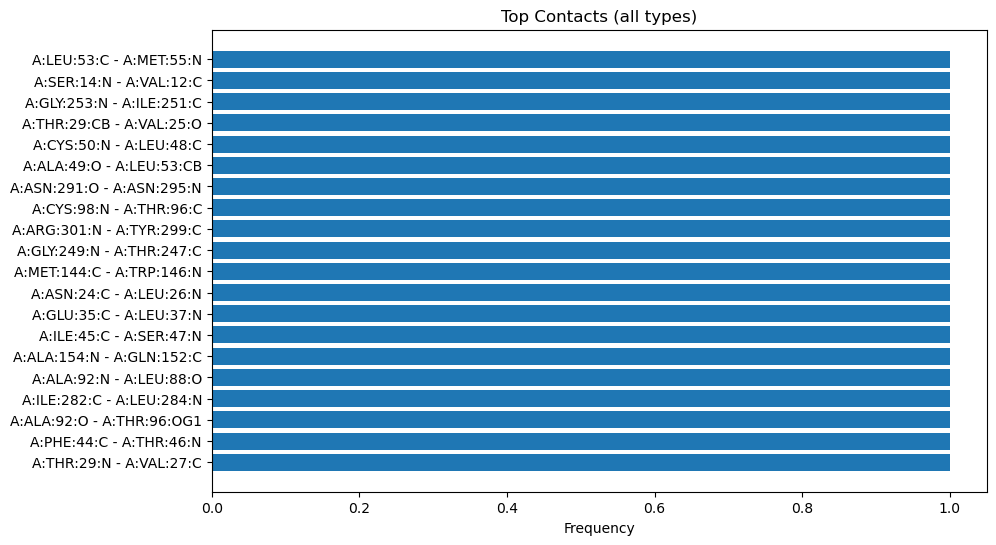

In [9]:
import matplotlib.pyplot as plt

top = freq.sort_values("frequency", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(top["atom1"] + " - " + top["atom2"], top["frequency"])
plt.gca().invert_yaxis()
plt.xlabel("Frequency")
plt.title("Top Contacts (all types)")
plt.show()

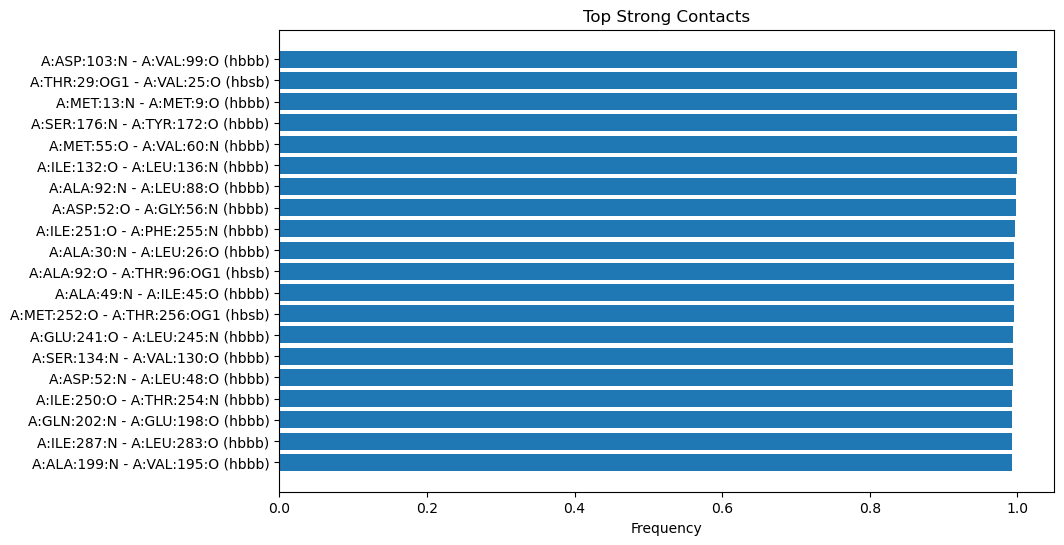

In [11]:
strong_types = ["hbss","hbsb","hbbb","sb","pc","ps","ts"]
strong = freq[freq["interaction_type"].isin(strong_types)]

top_strong = strong.sort_values("frequency", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(top_strong["atom1"] + " - " + top_strong["atom2"] + " (" + top_strong["interaction_type"] + ")",
         top_strong["frequency"])
plt.gca().invert_yaxis()
plt.xlabel("Frequency")
plt.title("Top Strong Contacts")
plt.show()

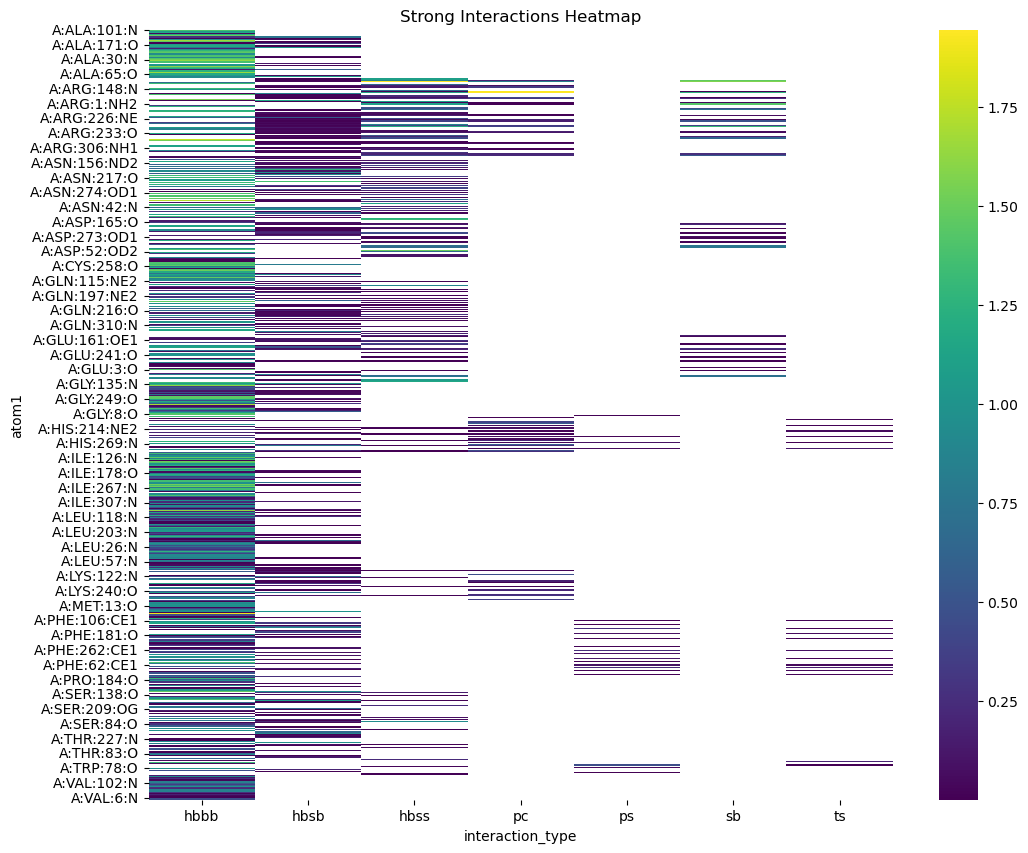

In [12]:
import seaborn as sns

pivot = strong.pivot_table(
    index="atom1",
    columns="interaction_type",
    values="frequency",
    aggfunc="sum"
)

plt.figure(figsize=(12,10))
sns.heatmap(pivot, cmap="viridis")
plt.title("Strong Interactions Heatmap")
plt.show()

In [1]:
import pandas as pd
import os

freq_dir = "/ocean/projects/che250002p/mtalib/B2A/bzv/getcontacts/frequencies"

files = [f for f in os.listdir(freq_dir) if f.endswith(".tsv")]

dfs = []

for f in files:
    
    path = os.path.join(freq_dir, f)
    
    df = pd.read_csv(
        path,
        sep="\t",
        comment="#",
        header=None,
        names=["res1","res2","frequency"]
    )
    
    # create interaction label
    df["contact"] = df["res1"] + "-" + df["res2"]
    
    # system name from file
    system = f.replace(".tsv","")
    df["system"] = system
    
    dfs.append(df)

all_contacts = pd.concat(dfs)

print(all_contacts.head())

        res1       res2  frequency              contact               system
0   A:LYS:33   A:THR:29      0.991    A:LYS:33-A:THR:29  Comp_15_frequencies
1  A:GLY:253  A:ILE:250      0.714  A:GLY:253-A:ILE:250  Comp_15_frequencies
2  A:GLN:272  A:ILE:276      0.910  A:GLN:272-A:ILE:276  Comp_15_frequencies
3  A:ASP:207  A:LYS:205      0.979  A:ASP:207-A:LYS:205  Comp_15_frequencies
4  A:ASN:217  A:HIS:214      0.817  A:ASN:217-A:HIS:214  Comp_15_frequencies


In [2]:
matrix = all_contacts.pivot_table(
    index="contact",
    columns="system",
    values="frequency",
    fill_value=0
)

In [3]:
top_contacts = matrix.mean(axis=1).sort_values(ascending=False).head(40)

matrix_top = matrix.loc[top_contacts.index]

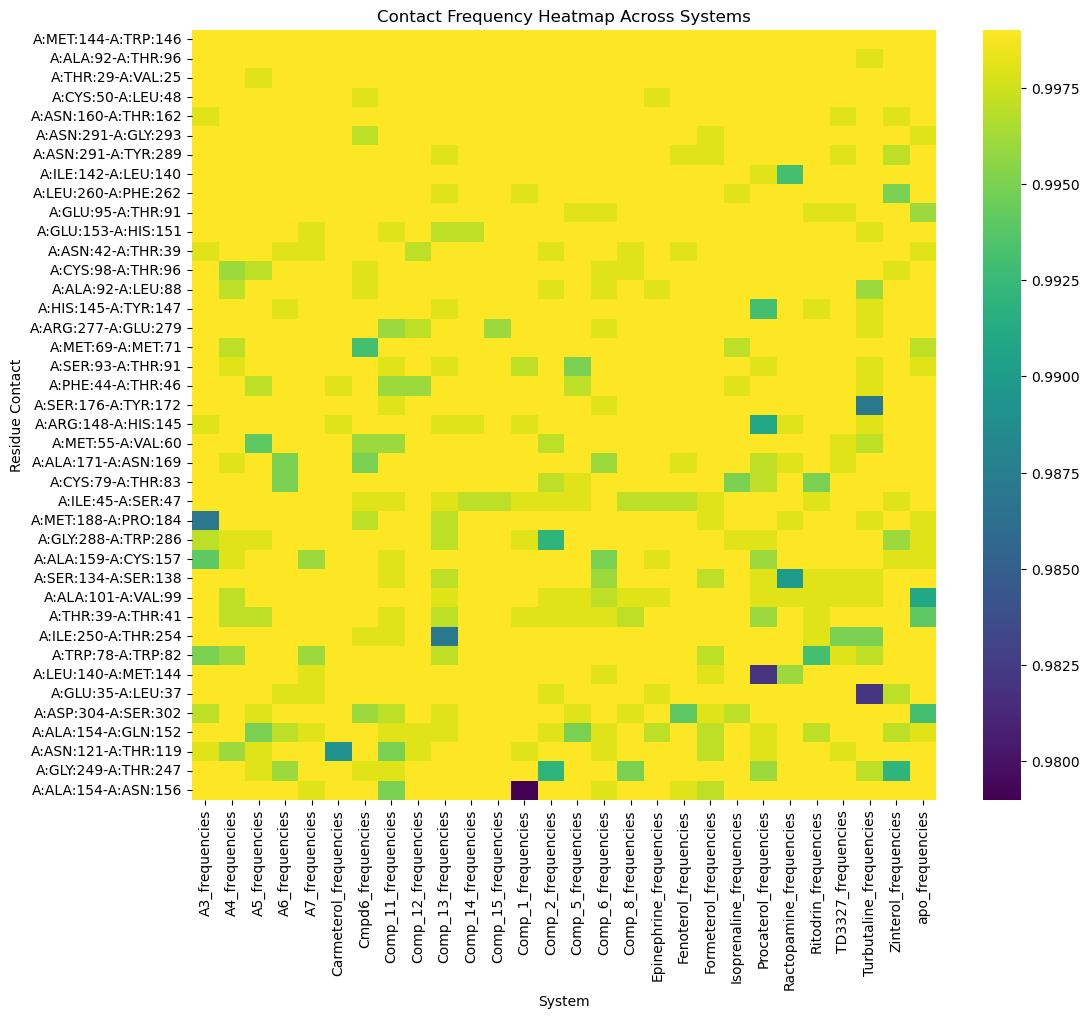

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    matrix_top,
    cmap="viridis"
)

plt.title("Contact Frequency Heatmap Across Systems")
plt.xlabel("System")
plt.ylabel("Residue Contact")

plt.show()

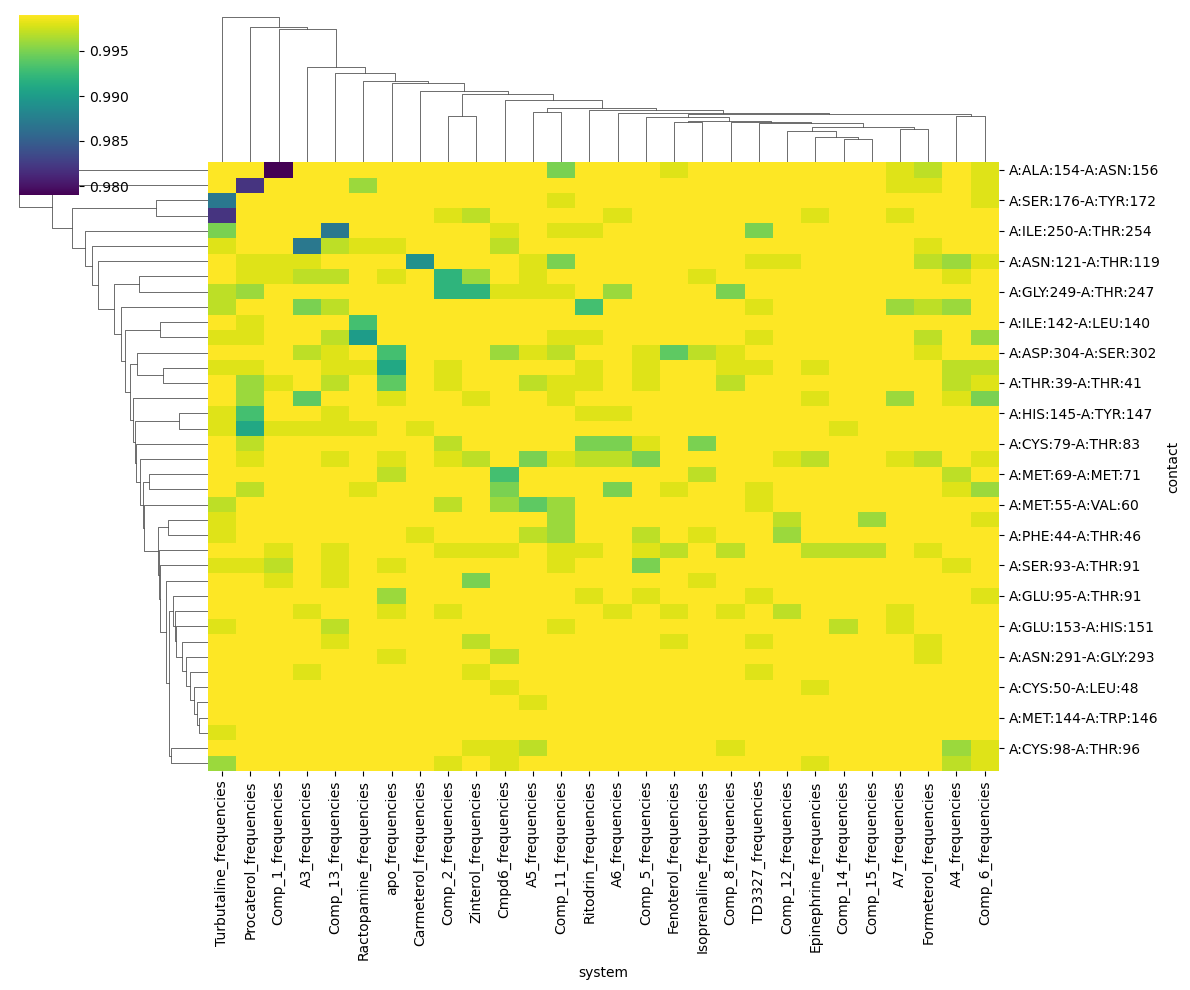

In [5]:
sns.clustermap(
    matrix_top,
    cmap="viridis",
    figsize=(12,10)
)

In [9]:
all_contacts["system"] = all_contacts["system"].str.replace("_frequencies","")

In [10]:
matrix = all_contacts.pivot_table(
    index="contact",
    columns="system",
    values="frequency",
    fill_value=0
)

In [11]:
top_contacts = matrix.mean(axis=1).sort_values(ascending=False).head(40)

matrix_top = matrix.loc[top_contacts.index]

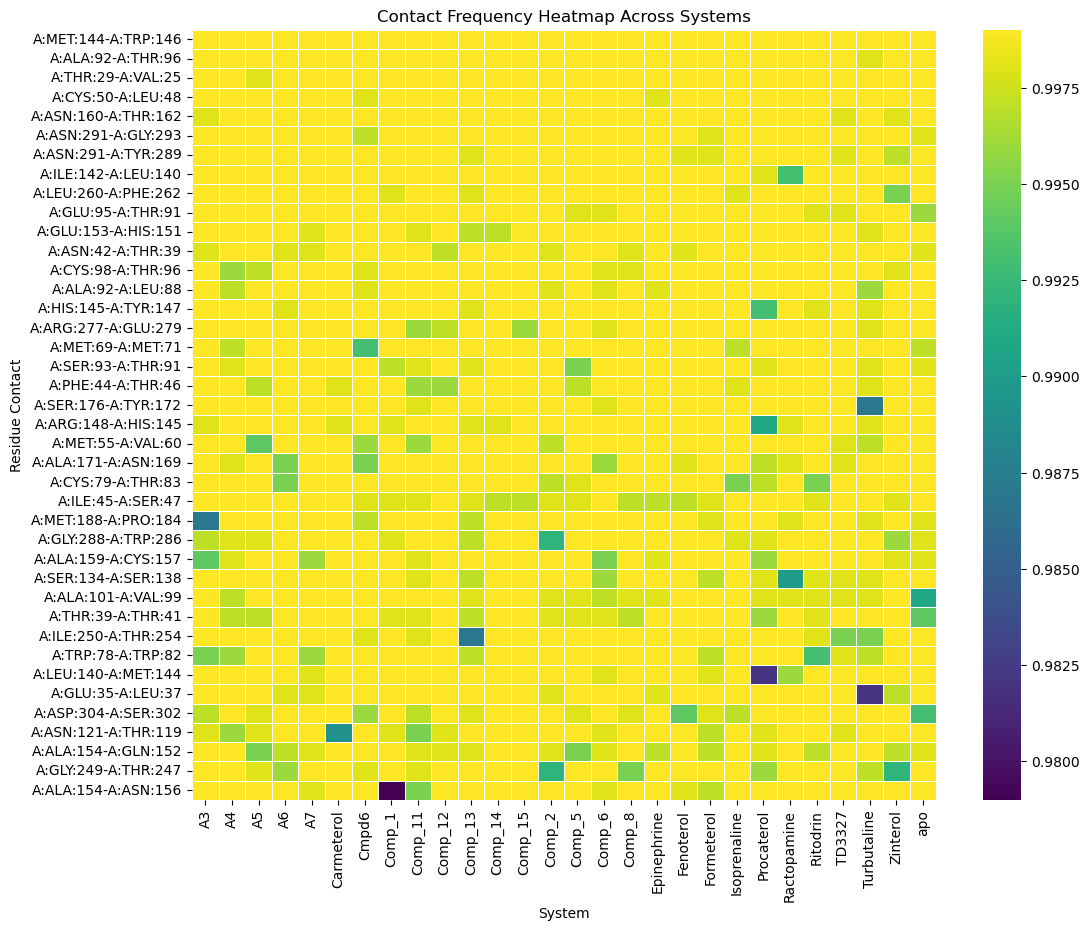

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    matrix_top,
    cmap="viridis",
    linewidths=0.5
)

plt.title("Contact Frequency Heatmap Across Systems")
plt.xlabel("System")
plt.ylabel("Residue Contact")

plt.show()

In [16]:
df["system"] = df["system"].str.replace("_frequencies", "", regex=False)

In [22]:
%who DataFrame
some_df.columns

all_contacts	 df	 matrix	 matrix_top	 


NameError: name 'some_df' is not defined

In [19]:
freq = (
    df.groupby(["interaction_type", "res1", "res2"])
      .size()
      .reset_index(name="count")
)

freq["frequency"] = freq["count"] / df["frame"].nunique()

KeyError: 'interaction_type'

In [15]:
import pandas as pd

path = "/ocean/projects/che250002p/mtalib/B2A/bzv/getcontacts/frequencies/A3_frequencies.tsv"

df = pd.read_csv(
    path,
    sep="\t",
    comment="#",
    header=None,
    names=["res1","res2","frequency"]
)

df.head()

ParserError: Error tokenizing data. C error: Expected 4 fields in line 2709, saw 6


In [13]:
print(df.columns)

Index(['res1', 'res2', 'frequency'], dtype='object')


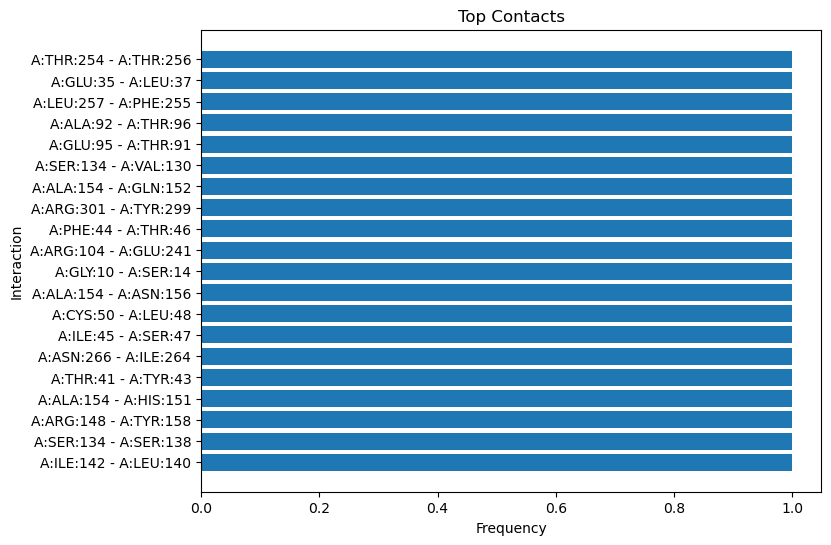

In [14]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values("frequency", ascending=False).head(20)

plt.figure(figsize=(8,6))
plt.barh(df_sorted["res1"] + " - " + df_sorted["res2"], df_sorted["frequency"])
plt.xlabel("Frequency")
plt.ylabel("Interaction")
plt.title("Top Contacts")
plt.gca().invert_yaxis()
plt.show()

In [3]:
freq_dir = "/ocean/projects/che250002p/mtalib/B2A/bzv/getcontacts/frequencies"

files = [f for f in os.listdir(freq_dir) if f.endswith(".tsv")]

data = {}

for f in files:
    path = os.path.join(freq_dir, f)
    df = pd.read_csv(path, sep="\t")
    data[f] = df

print("Loaded files:", len(data))

Loaded files: 28


In [4]:
df = list(data.values())[0]
df.head()

,,,#,total_frames:1000,"interaction_types:sb,pc,ps,ts,vdw,hb,lhb,hbbb,hbsb,hbss,wb,wb2,hbls,hblb,lwb,lwb2,br"
#,Columns:,"residue_1,",residue_2,frame_count,contact_frequency
A:LYS:33,A:THR:29,0.991,NaN,NaN,NaN
A:GLY:253,A:ILE:250,0.714,NaN,NaN,NaN
A:GLN:272,A:ILE:276,0.910,NaN,NaN,NaN
A:ASP:207,A:LYS:205,0.979,NaN,NaN,NaN


In [6]:
print(df.columns)

Index(['#', 'total_frames:1000',
       'interaction_types:sb,pc,ps,ts,vdw,hb,lhb,hbbb,hbsb,hbss,wb,wb2,hbls,hblb,lwb,lwb2,br'],
      dtype='object')


In [5]:
df_sorted = df.sort_values("frequency", ascending=False).head(20)

plt.figure(figsize=(8,6))
plt.barh(df_sorted["atom_1"] + "-" + df_sorted["atom_2"], df_sorted["frequency"])
plt.xlabel("Frequency")
plt.ylabel("Interaction")
plt.title("Top interactions")
plt.gca().invert_yaxis()
plt.show()


KeyError: 'frequency'